In [186]:
# q1
import pandas as pd
import numpy as np

In [187]:
# q2
data_frame = pd.read_csv("bhatbhateni_sales (1).csv")

In [188]:
#q3 a
data_frame.head()

,TransactionID,Date,CustomerID,CustomerName,Branch,ProductCategory,ProductName,Quantity,UnitPrice,TotalAmount,PaymentMethod
0,TXN101590,2025-05-19,CUST1100,Sujan Shrestha,Pokhara - Lakeside,Bakery,Chocolate Cake Slice,2,171.29,342.58,Khalti
1,TXN103282,2025-03-07,CUST1005,Milan Lama,Butwal - Traffic Chowk,Personal Care,Dove Soap,3,149.59,448.77,eSewa
2,TXN103539,2025-10-05,CUST1130,Alina Rai,Bhaktapur - Suryabinayak,Apparel,Winter Jacket,4,2794.25,11177.00,Khalti
3,TXN102479,2025-11-12,CUST1057,Neha Karki,Kathmandu - New Road,Household,Surf Excel 1kg,4,399.62,1598.48,Cash
4,TXN104408,2025-10-09,CUST1005,Milan Lama,Butwal - Traffic Chowk,Beverages,Gorkha Beer (6-pack),2,281.01,562.02,eSewa


In [189]:
#q3 b
print("Rows: ", data_frame.shape[0], "Columns: ", data_frame.shape[1])

Rows:  18812 Columns:  11


In [190]:
#q3 c
for column_name in data_frame.columns:
    print(column_name)



TransactionID
Date
CustomerID
CustomerName
Branch
ProductCategory
ProductName
Quantity
UnitPrice
TotalAmount
PaymentMethod


In [191]:
# Q4a - Data types
print(data_frame.dtypes)

TransactionID          str
Date                   str
CustomerID             str
CustomerName           str
Branch                 str
ProductCategory        str
ProductName            str
Quantity             int64
UnitPrice          float64
TotalAmount        float64
PaymentMethod          str
dtype: object


In [192]:
# Q4b - Summary statistics
data_frame.describe()

,Quantity,UnitPrice,TotalAmount
count,18812.000000,18441.000000,18812.000000
mean,2.506804,728.803530,1819.990565
std,1.114328,766.346109,2241.968350
min,1.000000,40.140000,40.610000
25%,2.000000,240.160000,488.397500
50%,3.000000,416.780000,989.000000
75%,3.000000,848.320000,2142.545000
max,4.000000,3499.280000,13997.120000


In [193]:
# Q5a - Missing values
missing = data_frame.isnull().sum()
missing_pct = (data_frame.isnull().sum() / len(data_frame) * 100).round(2)
missing_data_frame = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print('Missing values:')
print(missing_data_frame[missing_data_frame['Count'] > 0])
print(f'\nTotal rows with at least one null: {data_frame.isnull().any(axis=1).sum()}')

Missing values:
                 Count  Percentage
CustomerName       568        3.02
ProductCategory    282        1.50
UnitPrice          371        1.97
PaymentMethod      468        2.49

Total rows with at least one null: 1641


In [194]:
# Q5b - Fully duplicated rows
full_dupes = data_frame.duplicated().sum()
print(f'Fully duplicated rows: {full_dupes}')

Fully duplicated rows: 724


In [195]:
# Q5c - Distinguishing genuine repeat line-items from true duplicates
print('TransactionID repeats (multi-item baskets):')
txn_counts = data_frame['TransactionID'].value_counts()
print(f'  Transactions appearing more than once (by TransactionID only): {(txn_counts > 1).sum()}')
print(f'  Max items in a single transaction: {txn_counts.max()}')
print()
print('True duplicate rows (identical across ALL columns):')
print(f'  Count: {full_dupes}')
print()
print('Key distinction: A TransactionID repeating with DIFFERENT ProductName/other columns = multi-item basket (legitimate).')
print('A row that is 100% identical across all 11 columns = true duplicate that should be removed.')

TransactionID repeats (multi-item baskets):
  Transactions appearing more than once (by TransactionID only): 4860
  Max items in a single transaction: 7

True duplicate rows (identical across ALL columns):
  Count: 724

Key distinction: A TransactionID repeating with DIFFERENT ProductName/other columns = multi-item basket (legitimate).
A row that is 100% identical across all 11 columns = true duplicate that should be removed.


In [196]:
# Q5d - Illogical values: TotalAmount != Quantity * UnitPrice
valid = data_frame.dropna(subset=['Quantity', 'UnitPrice', 'TotalAmount'])
expected = valid['Quantity'] * valid['UnitPrice']
mismatch = valid[np.round(valid['TotalAmount'], 2) != np.round(expected, 2)]
print(f'Rows where TotalAmount != Quantity * UnitPrice: {len(mismatch)}')
if len(mismatch) > 0:
    display(mismatch.head(10))

Rows where TotalAmount != Quantity * UnitPrice: 0


In [197]:
# Q6a - Remove exact duplicate rows
rows_before = len(data_frame)
data_frame = data_frame.drop_duplicates().reset_index(drop=True)
rows_after = len(data_frame)

# Q6b - Verify
print(f'Rows before removing duplicates: {rows_before}')
print(f'Rows after removing duplicates:  {rows_after}')
print(f'Duplicates removed:               {rows_before - rows_after}')
print(f'Confirm no duplicates remain:     {data_frame.duplicated().sum() == 0}')

Rows before removing duplicates: 18812
Rows after removing duplicates:  18088
Duplicates removed:               724
Confirm no duplicates remain:     True


In [198]:
# Q7a - CustomerName: fill with 'Unknown Customer' (identity field, can't reliably impute)
data_frame['CustomerName'] = data_frame['CustomerName'].fillna('Unknown Customer')
print(f'CustomerName nulls remaining: {data_frame["CustomerName"].isnull().sum()}')

CustomerName nulls remaining: 0


In [199]:
# Q7b - ProductCategory: build a mapping from ProductName -> ProductCategory using non-null rows
product_cat_map = data_frame.dropna(subset=['ProductCategory']).drop_duplicates('ProductName').set_index('ProductName')['ProductCategory'].to_dict()
print(f'Known product-category mappings: {len(product_cat_map)}')

mask = data_frame['ProductCategory'].isnull()
data_frame.loc[mask, 'ProductCategory'] = data_frame.loc[mask, 'ProductName'].map(product_cat_map)

data_frame['ProductCategory'] = data_frame['ProductCategory'].fillna('Unknown')
print(f'ProductCategory nulls remaining: {data_frame["ProductCategory"].isnull().sum()}')

Known product-category mappings: 41
ProductCategory nulls remaining: 0


In [200]:
# Q7c - UnitPrice: first try TotalAmount / Quantity, then fall back to category-level median
null_price = data_frame['UnitPrice'].isnull()
print(f'UnitPrice nulls before imputation: {null_price.sum()}')

# Method 1: TotalAmount / Quantity
can_calc = null_price & data_frame['TotalAmount'].notna() & (data_frame['Quantity'] > 0)
data_frame.loc[can_calc, 'UnitPrice'] = data_frame.loc[can_calc, 'TotalAmount'] / data_frame.loc[can_calc, 'Quantity']
print(f'  Imputed via TotalAmount/Quantity: {can_calc.sum()}')

# Method 2: Category-level median for remaining
still_null = data_frame['UnitPrice'].isnull()
cat_medians = data_frame.groupby('ProductCategory')['UnitPrice'].transform('median')
data_frame.loc[still_null, 'UnitPrice'] = cat_medians[still_null]
print(f'  Imputed via category median: {still_null.sum()}')

print(f'UnitPrice nulls remaining: {data_frame["UnitPrice"].isnull().sum()}')

UnitPrice nulls before imputation: 362
  Imputed via TotalAmount/Quantity: 362
  Imputed via category median: 0
UnitPrice nulls remaining: 0


In [201]:
# Q7d - PaymentMethod: flag as 'Unknown' (don't impute - payment method is behavioral, not imputable)
data_frame['PaymentMethod'] = data_frame['PaymentMethod'].fillna('Unknown')
print(f'PaymentMethod nulls remaining: {data_frame["PaymentMethod"].isnull().sum()}')
print(f'Payment methods: {data_frame["PaymentMethod"].unique()}')

PaymentMethod nulls remaining: 0
Payment methods: <StringArray>
['Khalti', 'eSewa', 'Cash', 'Debit/Credit Card', 'Unknown', 'Bank Transfer']
Length: 6, dtype: str


In [202]:
# Q7e - Confirm no remaining missing values
remaining = data_frame.isnull().sum()
print('Remaining missing values per column:')
print(remaining)
print(f'\nTotal nulls in dataset: {remaining.sum()}')

Remaining missing values per column:
TransactionID      0
Date               0
CustomerID         0
CustomerName       0
Branch             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
TotalAmount        0
PaymentMethod      0
dtype: int64

Total nulls in dataset: 0


In [203]:
# Q8a - Convert Date to datetime and extract time features
data_frame['Date'] = pd.to_datetime(data_frame['Date'])
data_frame['Year'] = data_frame['Date'].dt.year
data_frame['Month'] = data_frame['Date'].dt.month
data_frame['Day'] = data_frame['Date'].dt.day
data_frame['DayOfWeek'] = data_frame['Date'].dt.day_name()
data_frame['Weekend'] = data_frame['Date'].dt.dayofweek >= 5
data_frame['MonthName'] = data_frame['Date'].dt.month_name()

print('Date features extracted:')
print(data_frame[['Date', 'Year', 'Month', 'MonthName', 'Day', 'DayOfWeek', 'Weekend']].head(10))

Date features extracted:
        Date  Year  Month MonthName  Day  DayOfWeek  Weekend
0 2025-05-19  2025      5       May   19     Monday    False
1 2025-03-07  2025      3     March    7     Friday    False
2 2025-10-05  2025     10   October    5     Sunday     True
3 2025-11-12  2025     11  November   12  Wednesday    False
4 2025-10-09  2025     10   October    9   Thursday    False
5 2025-01-16  2025      1   January   16   Thursday    False
6 2025-10-21  2025     10   October   21    Tuesday    False
7 2025-11-01  2025     11  November    1   Saturday     True
8 2025-05-04  2025      5       May    4     Sunday     True
9 2025-07-13  2025      7      July   13     Sunday     True


In [204]:
# Q8b - Extract City from Branch
data_frame['City'] = data_frame['Branch'].apply(lambda x: x.split(' - ')[0] if pd.notna(x) else 'Unknown')
print('Cities:')
print(data_frame['City'].unique())

Cities:
<StringArray>
[   'Pokhara',     'Butwal',  'Bhaktapur',  'Kathmandu',   'Lalitpur',
 'Biratnagar',    'Chitwan']
Length: 7, dtype: str


In [205]:
# Q8c - Recompute TotalAmount = Quantity * UnitPrice
data_frame['TotalAmount'] = data_frame['Quantity'] * data_frame['UnitPrice']
print('TotalAmount recomputed from Quantity * UnitPrice')
print(data_frame[['Quantity', 'UnitPrice', 'TotalAmount']].head(10))

TotalAmount recomputed from Quantity * UnitPrice
   Quantity  UnitPrice  TotalAmount
0         2     171.29       342.58
1         3     149.59       448.77
2         4    2794.25     11177.00
3         4     399.62      1598.48
4         2     281.01       562.02
5         3     223.65       670.95
6         3     437.17      1311.51
7         4    1630.72      6522.88
8         2     383.62       767.24
9         1     448.71       448.71


In [206]:
import matplotlib.pyplot as plt

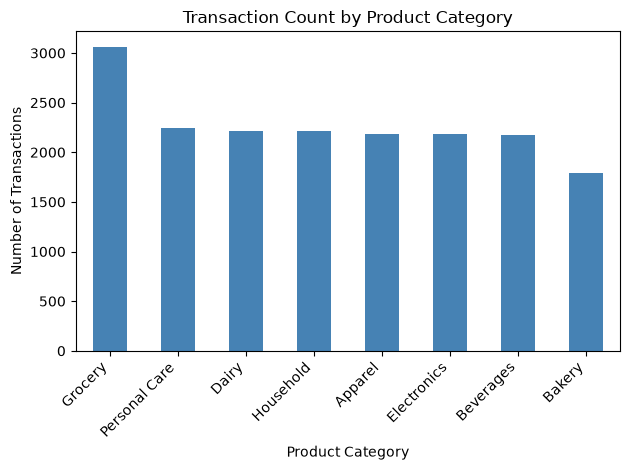

ProductCategory
Grocery          3065
Personal Care    2246
Dairy            2217
Household        2212
Apparel          2188
Electronics      2186
Beverages        2179
Bakery           1795
Name: count, dtype: int64


In [207]:
# Q9a - Product category distribution
fig, ax = plt.subplots()
cat_counts = data_frame['ProductCategory'].value_counts()
cat_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Transaction Count by Product Category')
ax.set_ylabel('Number of Transactions')
ax.set_xlabel('Product Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(cat_counts)

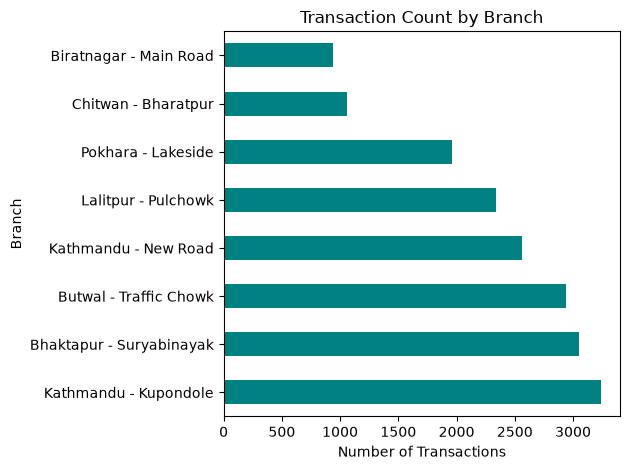

Branch
Kathmandu - Kupondole       3241
Bhaktapur - Suryabinayak    3050
Butwal - Traffic Chowk      2940
Kathmandu - New Road        2561
Lalitpur - Pulchowk         2337
Pokhara - Lakeside          1957
Chitwan - Bharatpur         1063
Biratnagar - Main Road       939
Name: count, dtype: int64


In [208]:
# Q9b - Branch distribution
fig, ax = plt.subplots()
branch_counts = data_frame['Branch'].value_counts()
branch_counts.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Transaction Count by Branch')
ax.set_xlabel('Number of Transactions')
plt.tight_layout()
plt.show()
print(branch_counts)

Payment method frequency:
PaymentMethod
Cash                 6218
eSewa                4951
Khalti               3795
Debit/Credit Card    1813
Bank Transfer         859
Unknown               452
Name: count, dtype: int64

Most common: Cash (6218 transactions)


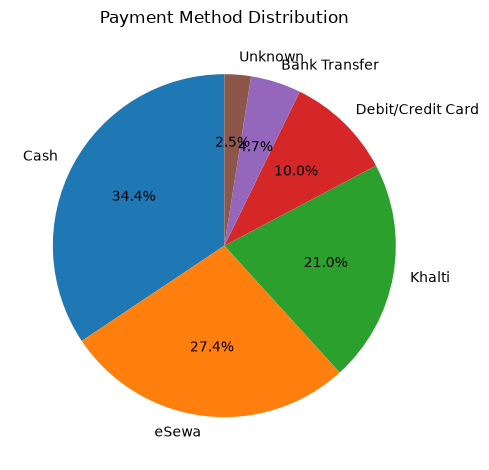

In [209]:
# Q9c - Payment method usage
payment_counts = data_frame['PaymentMethod'].value_counts()
print('Payment method frequency:')
print(payment_counts)
print(f'\nMost common: {payment_counts.index[0]} ({payment_counts.iloc[0]} transactions)')

fig, ax = plt.subplots()
payment_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
ax.set_title('Payment Method Distribution')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

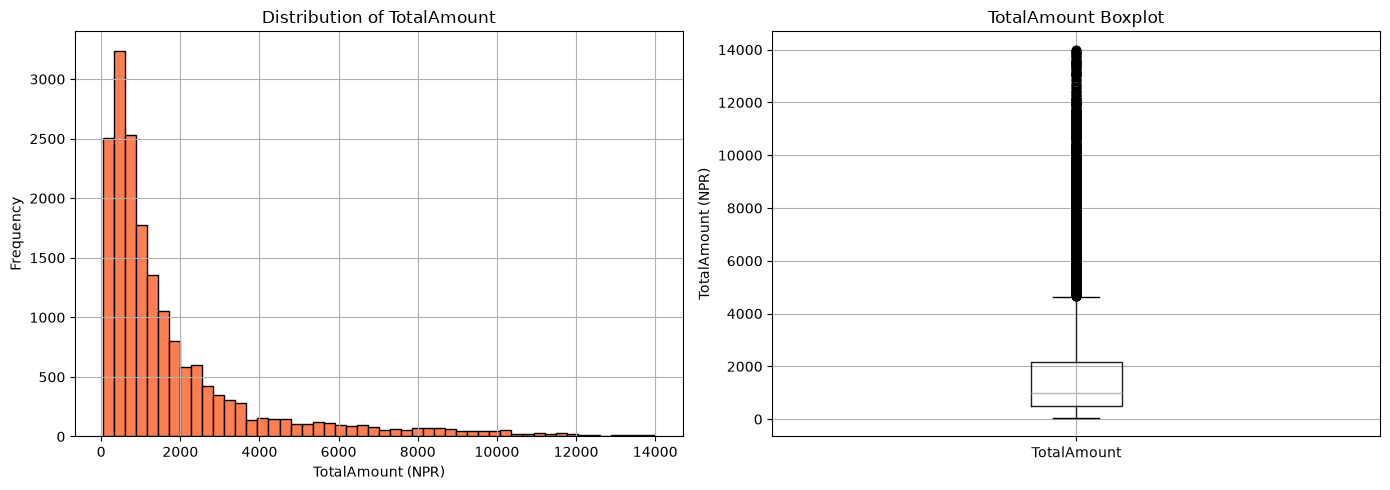

Skewness: 2.46
Mean:     1824.64
Median:   990.50
Std Dev:  2245.52


In [210]:
# Q9d - TotalAmount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_frame['TotalAmount'].hist(bins=50, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Distribution of TotalAmount')
axes[0].set_xlabel('TotalAmount (NPR)')
axes[0].set_ylabel('Frequency')

data_frame.boxplot(column='TotalAmount', ax=axes[1])
axes[1].set_title('TotalAmount Boxplot')
axes[1].set_ylabel('TotalAmount (NPR)')

plt.tight_layout()
plt.show()

print(f'Skewness: {data_frame["TotalAmount"].skew():.2f}')
print(f'Mean:     {data_frame["TotalAmount"].mean():.2f}')
print(f'Median:   {data_frame["TotalAmount"].median():.2f}')
print(f'Std Dev:  {data_frame["TotalAmount"].std():.2f}')

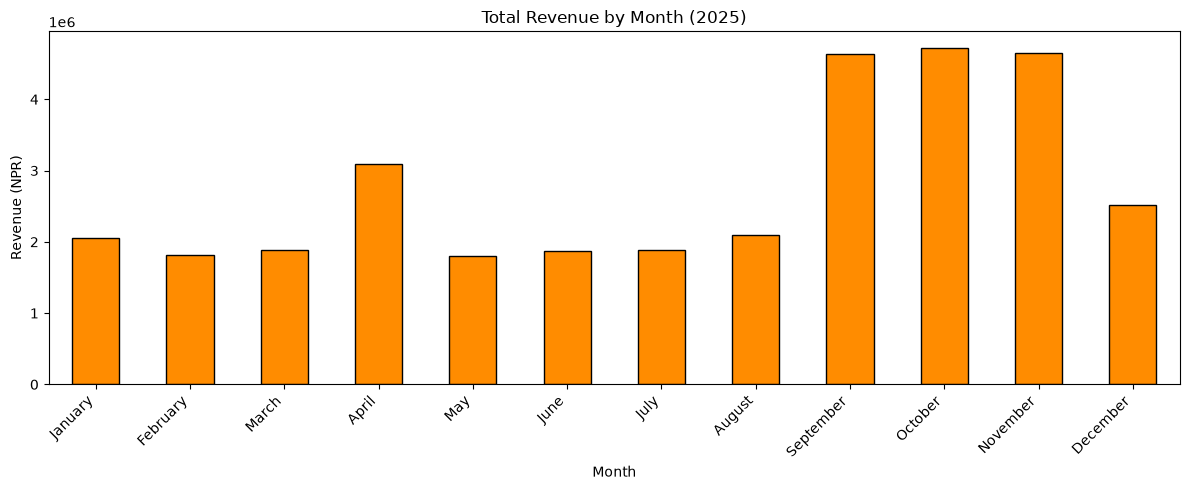

MonthName
January      2047697.10
February     1813821.23
March        1887644.85
April        3088404.52
May          1804819.74
June         1875854.82
July         1881584.08
August       2096176.94
September    4630698.52
October      4717670.71
November     4647417.42
December     2512355.71
Name: TotalAmount, dtype: float64


In [211]:
# Q10a - Monthly revenue trend
monthly_rev = data_frame.groupby('MonthName')['TotalAmount'].sum()
# Order by month
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_rev = monthly_rev.reindex([m for m in month_order if m in monthly_rev.index])

fig, ax = plt.subplots(figsize=(12, 5))
monthly_rev.plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('Total Revenue by Month (2025)')
ax.set_ylabel('Revenue (NPR)')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(monthly_rev)

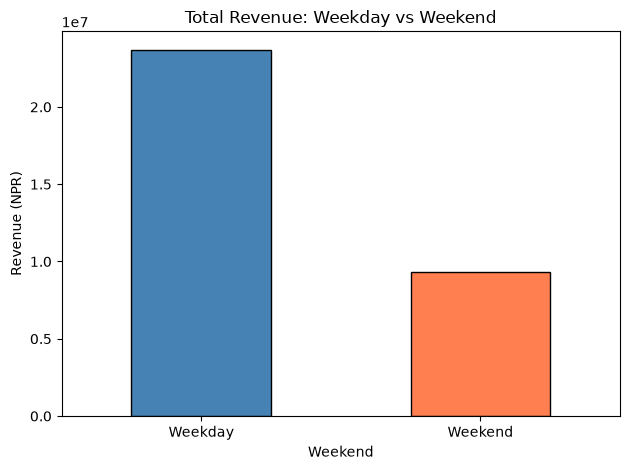

Weekend
False    23705495.89
True      9298649.75
Name: TotalAmount, dtype: float64


In [212]:
# Q10b - Weekend vs Weekday sales
weekend_sales = data_frame.groupby('Weekend')['TotalAmount'].sum()
fig, ax = plt.subplots()
weekend_sales.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
ax.set_xticklabels(['Weekday', 'Weekend'], rotation=0)
ax.set_title('Total Revenue: Weekday vs Weekend')
ax.set_ylabel('Revenue (NPR)')
plt.tight_layout()
plt.show()
print(weekend_sales)

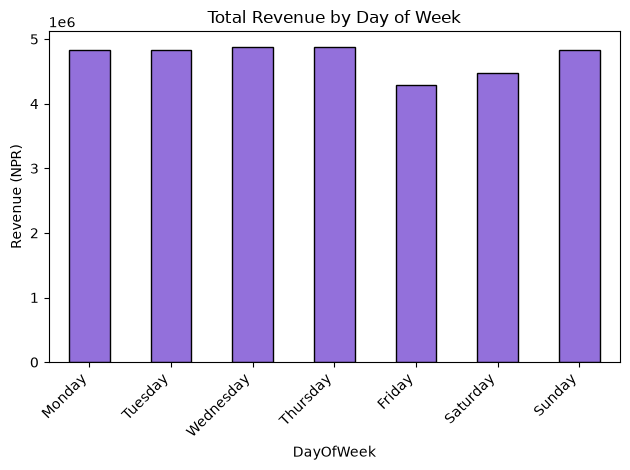

DayOfWeek
Monday       4826070.64
Tuesday      4836536.99
Wednesday    4874642.96
Thursday     4876393.65
Friday       4291851.65
Saturday     4474756.59
Sunday       4823893.16
Name: TotalAmount, dtype: float64

Highest revenue day: Thursday (NPR 4,876,393.65)


In [213]:
# Q10c - Revenue by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = data_frame.groupby('DayOfWeek')['TotalAmount'].sum().reindex(day_order)

fig, ax = plt.subplots()
dow_rev.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Total Revenue by Day of Week')
ax.set_ylabel('Revenue (NPR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(dow_rev)
print(f'\nHighest revenue day: {dow_rev.idxmax()} (NPR {dow_rev.max():,.2f})')

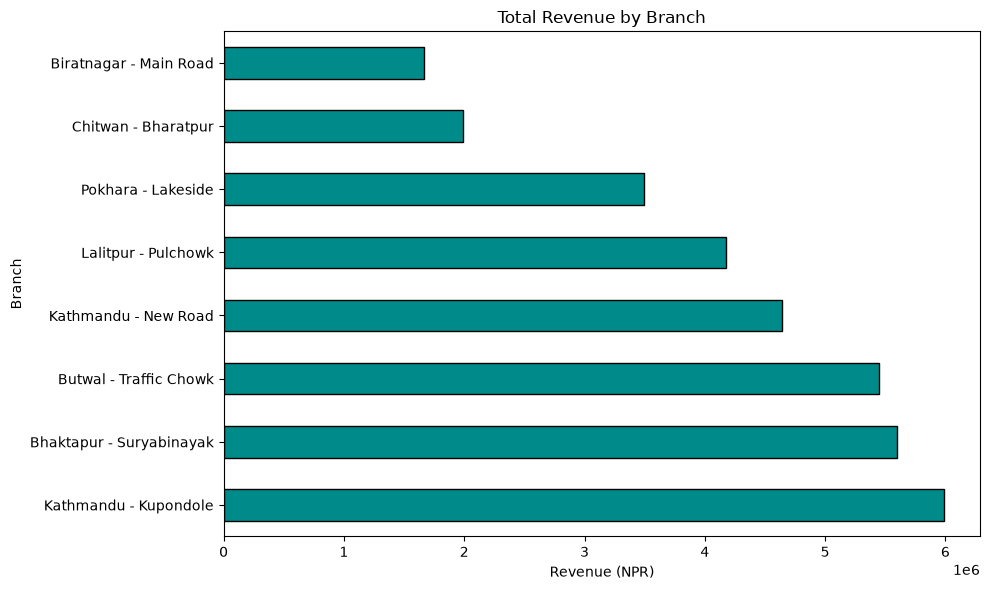

Branch
Kathmandu - Kupondole       5988126.62
Bhaktapur - Suryabinayak    5597500.45
Butwal - Traffic Chowk      5448358.25
Kathmandu - New Road        4641030.50
Lalitpur - Pulchowk         4173146.13
Pokhara - Lakeside          3494044.41
Chitwan - Bharatpur         1994033.40
Biratnagar - Main Road      1667905.88
Name: TotalAmount, dtype: float64

Top branch: Kathmandu - Kupondole (NPR 5,988,126.62)


In [214]:
# Q11a - Revenue by branch
branch_rev = data_frame.groupby('Branch')['TotalAmount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
branch_rev.plot(kind='barh', ax=ax, color='darkcyan', edgecolor='black')
ax.set_title('Total Revenue by Branch')
ax.set_xlabel('Revenue (NPR)')
plt.tight_layout()
plt.show()
print(branch_rev)
print(f'\nTop branch: {branch_rev.index[0]} (NPR {branch_rev.iloc[0]:,.2f})')

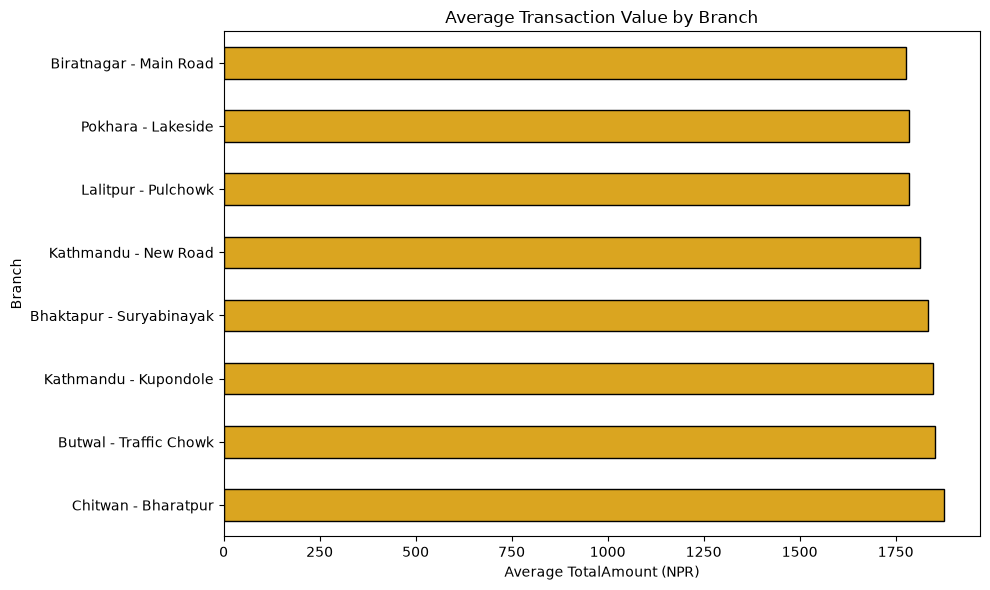

Branch
Chitwan - Bharatpur         1875.85
Butwal - Traffic Chowk      1853.18
Kathmandu - Kupondole       1847.62
Bhaktapur - Suryabinayak    1835.25
Kathmandu - New Road        1812.19
Lalitpur - Pulchowk         1785.69
Pokhara - Lakeside          1785.41
Biratnagar - Main Road      1776.26
Name: TotalAmount, dtype: float64


In [215]:
# Q11b - Average transaction value by branch
branch_avg = data_frame.groupby('Branch')['TotalAmount'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
branch_avg.plot(kind='barh', ax=ax, color='goldenrod', edgecolor='black')
ax.set_title('Average Transaction Value by Branch')
ax.set_xlabel('Average TotalAmount (NPR)')
plt.tight_layout()
plt.show()
print(branch_avg.round(2))

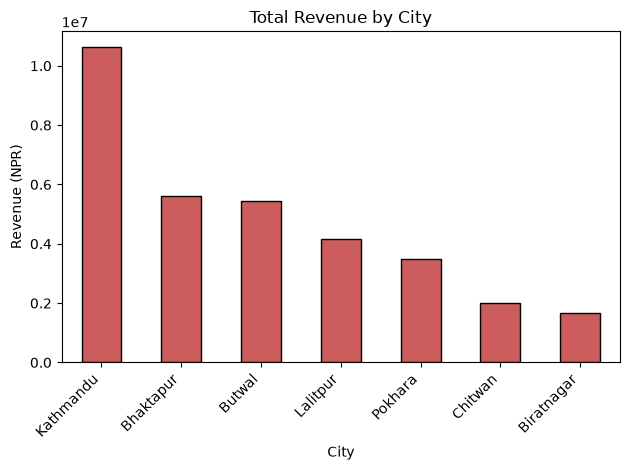

City
Kathmandu     10629157.12
Bhaktapur      5597500.45
Butwal         5448358.25
Lalitpur       4173146.13
Pokhara        3494044.41
Chitwan        1994033.40
Biratnagar     1667905.88
Name: TotalAmount, dtype: float64

Top city: Kathmandu (NPR 10,629,157.12)


In [216]:
# Q11c - Revenue by city
city_rev = data_frame.groupby('City')['TotalAmount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
city_rev.plot(kind='bar', ax=ax, color='indianred', edgecolor='black')
ax.set_title('Total Revenue by City')
ax.set_ylabel('Revenue (NPR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(city_rev)
print(f'\nTop city: {city_rev.index[0]} (NPR {city_rev.iloc[0]:,.2f})')

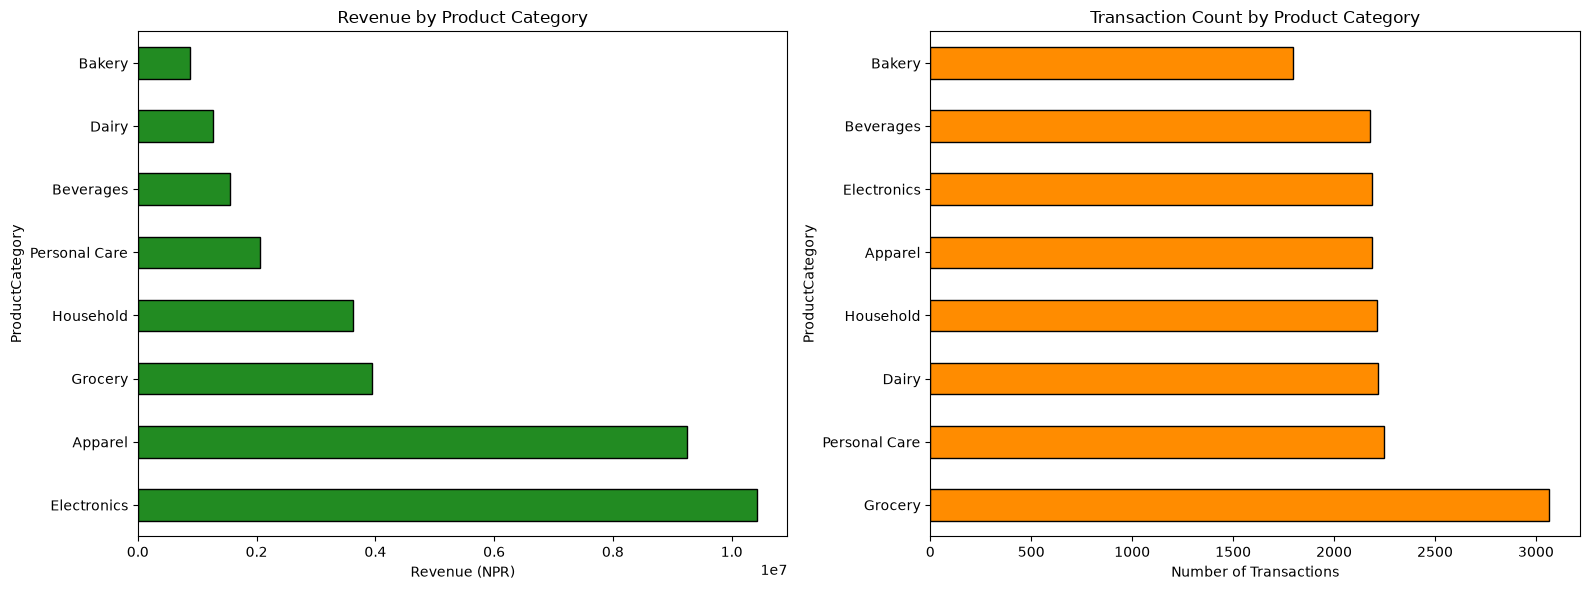

Revenue by category:
ProductCategory
Electronics      10419134.62
Apparel           9251535.64
Grocery           3943021.00
Household         3620342.47
Personal Care     2064900.31
Beverages         1558152.52
Dairy             1260518.61
Bakery             886540.47
Name: TotalAmount, dtype: float64

Transaction count by category:
ProductCategory
Grocery          3065
Personal Care    2246
Dairy            2217
Household        2212
Apparel          2188
Electronics      2186
Beverages        2179
Bakery           1795
Name: count, dtype: int64


In [217]:
# Q12a - Revenue vs Transaction count by category
cat_rev = data_frame.groupby('ProductCategory')['TotalAmount'].sum().sort_values(ascending=False)
cat_txn = data_frame['ProductCategory'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_rev.plot(kind='barh', ax=axes[0], color='forestgreen', edgecolor='black')
axes[0].set_title('Revenue by Product Category')
axes[0].set_xlabel('Revenue (NPR)')

cat_txn.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Transaction Count by Product Category')
axes[1].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()
print('Revenue by category:')
print(cat_rev)
print('\nTransaction count by category:')
print(cat_txn)

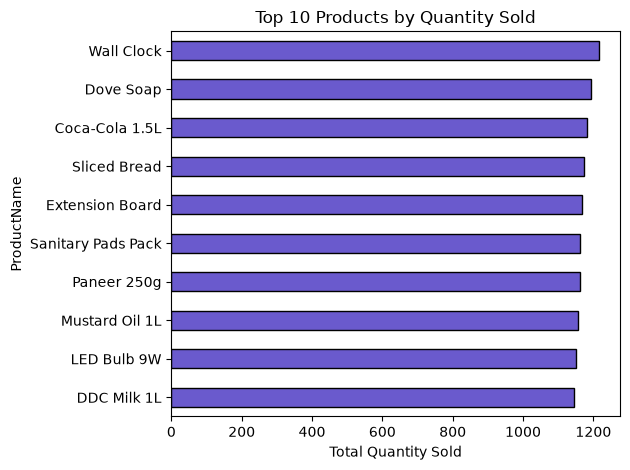

ProductName
Wall Clock            1215
Dove Soap             1194
Coca-Cola 1.5L        1183
Sliced Bread          1174
Extension Board       1167
Sanitary Pads Pack    1163
Paneer 250g           1163
Mustard Oil 1L        1157
LED Bulb 9W           1150
DDC Milk 1L           1146
Name: Quantity, dtype: int64


In [218]:
# Q12b - Top 10 products by quantity sold
top_qty = data_frame.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
top_qty.plot(kind='barh', ax=ax, color='slateblue', edgecolor='black')
ax.set_title('Top 10 Products by Quantity Sold')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(top_qty)

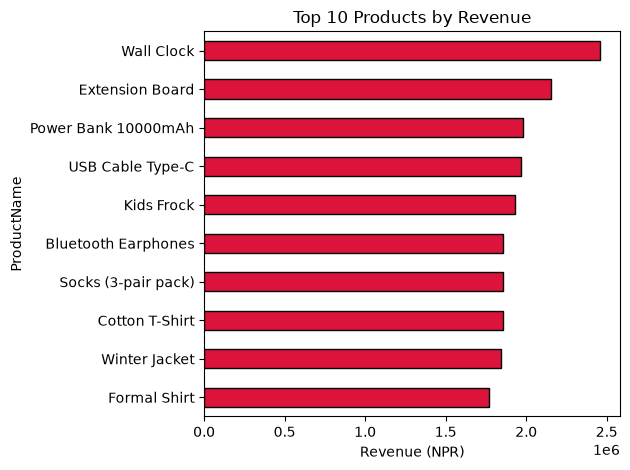

ProductName
Wall Clock             2459453.52
Extension Board        2155259.21
Power Bank 10000mAh    1977709.90
USB Cable Type-C       1968887.55
Kids Frock             1928877.20
Bluetooth Earphones    1857824.44
Socks (3-pair pack)    1855597.09
Cotton T-Shirt         1854507.38
Winter Jacket          1842626.06
Formal Shirt           1769927.91
Name: TotalAmount, dtype: float64


In [219]:
# Q12c - Top 10 products by revenue
top_rev = data_frame.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
top_rev.plot(kind='barh', ax=ax, color='crimson', edgecolor='black')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue (NPR)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(top_rev.round(2))

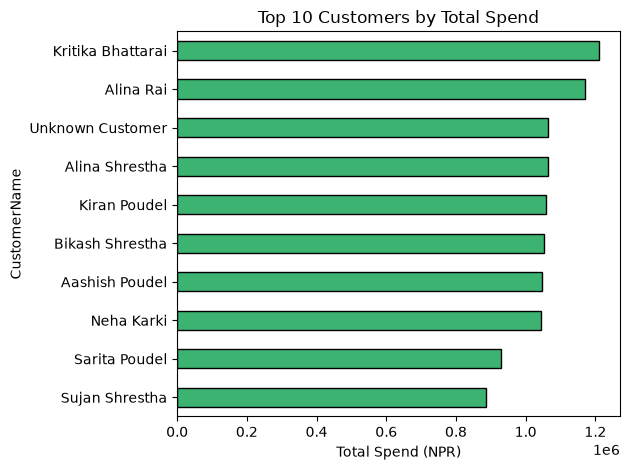

CustomerName
Kritika Bhattarai    1210202.18
Alina Rai            1170925.25
Unknown Customer     1064651.27
Alina Shrestha       1063044.88
Kiran Poudel         1058165.81
Bikash Shrestha      1053659.23
Aashish Poudel       1045754.25
Neha Karki           1043193.73
Sarita Poudel         928717.65
Sujan Shrestha        887527.87
Name: TotalAmount, dtype: float64


In [220]:
# Q13a - Top 10 customers by total spend
top_cust = data_frame.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots()
top_cust.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='black')
ax.set_title('Top 10 Customers by Total Spend')
ax.set_xlabel('Total Spend (NPR)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(top_cust.round(2))

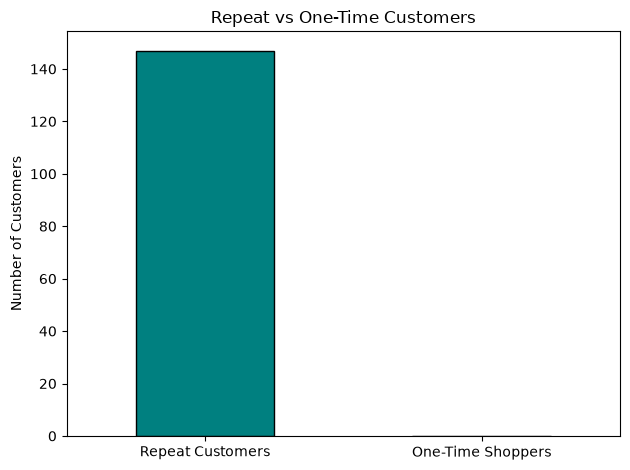

Repeat customers:    147
One-time shoppers:  0
Total unique customers: 147


In [221]:
# Q13b - Repeat vs one-time customers
cust_txn_count = data_frame.groupby('CustomerID').size()
repeat = (cust_txn_count > 1).sum()
one_time = (cust_txn_count == 1).sum()

fig, ax = plt.subplots()
pd.Series({'Repeat Customers': repeat, 'One-Time Shoppers': one_time}).plot(
    kind='bar', ax=ax, color=['teal', 'salmon'], edgecolor='black')
ax.set_title('Repeat vs One-Time Customers')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
print(f'Repeat customers:    {repeat}')
print(f'One-time shoppers:  {one_time}')
print(f'Total unique customers: {len(cust_txn_count)}')

In [222]:
# Q13c - Average spend per customer (CLV proxy)
cust_spend = data_frame.groupby('CustomerID')['TotalAmount'].sum()
print(f'Average spend per customer: NPR {cust_spend.mean():,.2f}')
print(f'Median spend per customer:  NPR {cust_spend.median():,.2f}')
print(f'Max spend per customer:     NPR {cust_spend.max():,.2f}')
print(f'Min spend per customer:     NPR {cust_spend.min():,.2f}')

Average spend per customer: NPR 224,518.00
Median spend per customer:  NPR 142,014.75
Max spend per customer:     NPR 1,286,840.72
Min spend per customer:     NPR 3,365.50


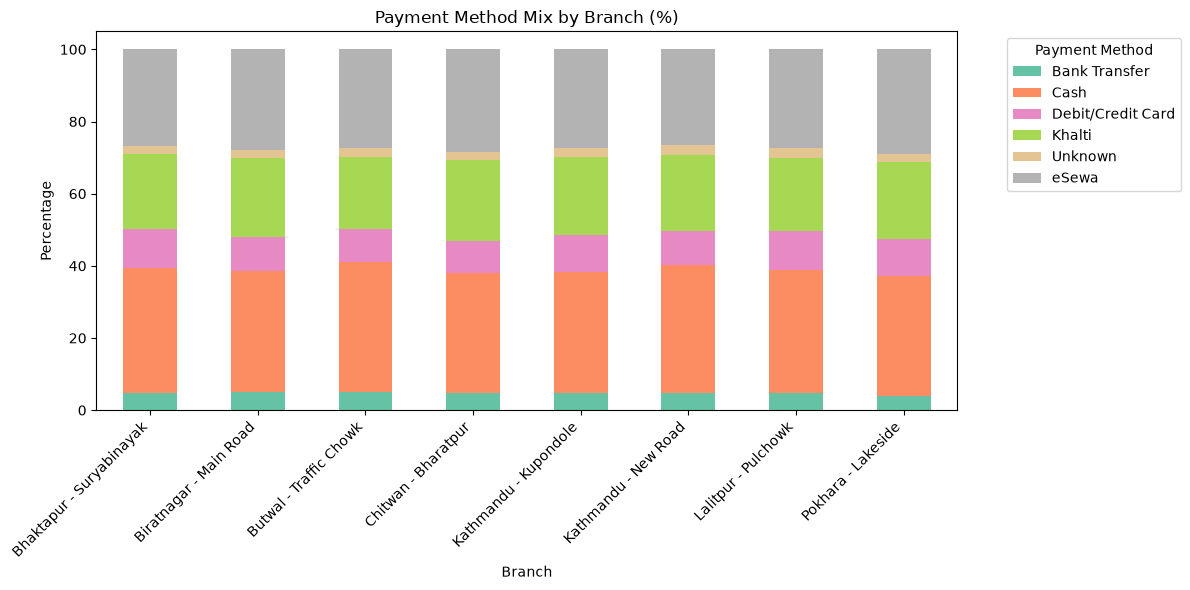

PaymentMethod             Bank Transfer  Cash  Debit/Credit Card  Khalti  \
Branch                                                                     
Bhaktapur - Suryabinayak            4.8  34.6               10.7    20.9   
Biratnagar - Main Road              5.0  33.4                9.5    21.8   
Butwal - Traffic Chowk              5.0  35.9                9.4    20.0   
Chitwan - Bharatpur                 4.7  33.4                8.7    22.6   
Kathmandu - Kupondole               4.9  33.4               10.3    21.6   
Kathmandu - New Road                4.7  35.6                9.3    21.1   
Lalitpur - Pulchowk                 4.8  34.1               10.9    20.2   
Pokhara - Lakeside                  3.9  33.2               10.4    21.3   

PaymentMethod             Unknown  eSewa  
Branch                                    
Bhaktapur - Suryabinayak      2.3   26.7  
Biratnagar - Main Road        2.4   27.8  
Butwal - Traffic Chowk        2.3   27.4  
Chitwan - Bharatpur     

In [223]:
# Q14a - Payment method by branch
pay_branch = pd.crosstab(data_frame['Branch'], data_frame['PaymentMethod'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 6))
pay_branch.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Payment Method Mix by Branch (%)')
ax.set_ylabel('Percentage')
ax.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(pay_branch.round(1))

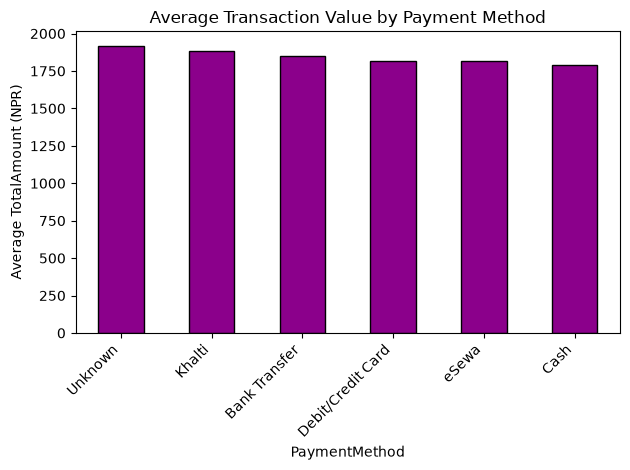

PaymentMethod
Unknown              1918.80
Khalti               1881.37
Bank Transfer        1849.67
Debit/Credit Card    1819.48
eSewa                1815.58
Cash                 1788.44
Name: TotalAmount, dtype: float64


In [224]:
# Q14b - Average transaction value by payment method
pay_avg = data_frame.groupby('PaymentMethod')['TotalAmount'].mean().sort_values(ascending=False)
fig, ax = plt.subplots()
pay_avg.plot(kind='bar', ax=ax, color='darkmagenta', edgecolor='black')
ax.set_title('Average Transaction Value by Payment Method')
ax.set_ylabel('Average TotalAmount (NPR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(pay_avg.round(2))

In [225]:
import seaborn as sns

Correlation matrix:
             Quantity  UnitPrice  TotalAmount
Quantity        1.000     -0.005        0.361
UnitPrice      -0.005      1.000        0.848
TotalAmount     0.361      0.848        1.000


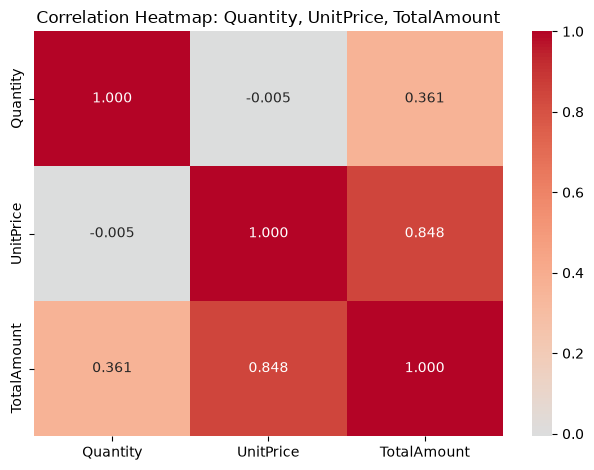

In [226]:
# Q15a - Correlation
corr = data_frame[['Quantity', 'UnitPrice', 'TotalAmount']].corr()
print('Correlation matrix:')
print(corr.round(3))

fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax, fmt='.3f')
ax.set_title('Correlation Heatmap: Quantity, UnitPrice, TotalAmount')
plt.tight_layout()
plt.show()

In [227]:
# Q15b - Outlier detection using IQR
Q1 = data_frame['TotalAmount'].quantile(0.25)
Q3 = data_frame['TotalAmount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data_frame[(data_frame['TotalAmount'] < lower) | (data_frame['TotalAmount'] > upper)]
print(f'IQR bounds: [{lower:,.2f}, {upper:,.2f}]')
print(f'Number of outlier transactions: {len(outliers)} ({len(outliers)/len(data_frame)*100:.1f}%)')
print(f'\nOutlier statistics:')
print(outliers['TotalAmount'].describe())

IQR bounds: [-2,007.41, 4,648.61]
Number of outlier transactions: 1763 (9.7%)

Outlier statistics:
count     1763.000000
mean      7631.404901
std       2265.165122
min       4649.520000
25%       5747.720000
50%       7085.160000
75%       9096.580000
max      13997.120000
Name: TotalAmount, dtype: float64


In [228]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error


In [229]:
# Q16a - Build a simple linear regression model
model_data_frame = data_frame[['Quantity', 'UnitPrice', 'Branch', 'ProductCategory', 'TotalAmount']].copy()

# Encode categorical features
le_branch = LabelEncoder()
le_cat = LabelEncoder()
model_data_frame['Branch_enc'] = le_branch.fit_transform(model_data_frame['Branch'])
model_data_frame['Category_enc'] = le_cat.fit_transform(model_data_frame['ProductCategory'])

X = model_data_frame[['Quantity', 'UnitPrice', 'Branch_enc', 'Category_enc']]
y = model_data_frame['TotalAmount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R-squared: {r2:.4f}')
print(f'Mean Absolute Error: NPR {mae:,.2f}')

R-squared: 0.8476
Mean Absolute Error: NPR 562.58


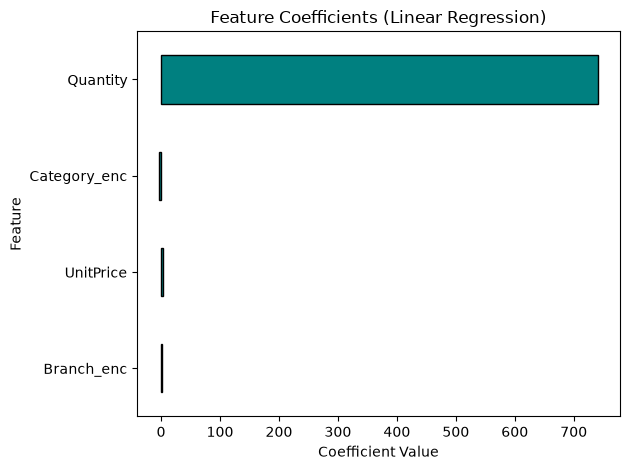

     Feature  Coefficient
    Quantity   741.256912
Category_enc    -3.286173
   UnitPrice     2.493421
  Branch_enc     0.820487

Intercept: -1,844.98


In [230]:
# Q16b - Feature importance
coef_data_frame = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_data_frame['AbsCoefficient'] = coef_data_frame['Coefficient'].abs()
coef_data_frame = coef_data_frame.sort_values('AbsCoefficient', ascending=False)

fig, ax = plt.subplots()
coef_data_frame.plot(kind='barh', x='Feature', y='Coefficient', ax=ax, color='teal', edgecolor='black', legend=False)
ax.set_title('Feature Coefficients (Linear Regression)')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(coef_data_frame[['Feature', 'Coefficient']].to_string(index=False))
print(f'\nIntercept: {model.intercept_:,.2f}')